# 02 — Multi-CDP Visual Test: Hill Climbing vs Random Search

Before implementing Tabu Search, this notebook applies the already-built
**Hill Climbing** and **Random Search** to a new stage of the problem:
instead of a single CDP, we use **5 neighboring columns** of the
Marmousi2 model (a small "2D slice").

Each panel is still solved **independently** — there is no lateral
continuity penalty between the 5 CDPs yet; that coupling is the next
step, together with Tabu Search. The goal here is purely **visual**: one
run of each algorithm per panel, not the 30-run / 33,000-eval
statistical protocol used for the Trabalho 1 report.

**Data:** loaded from `MODEL_P-WAVE_VELOCITY_1.25m.segy` (previously
`.bin`) — `load_marmousi2_velocity` auto-detects whichever of the two
files is present in `data/models/marmousi2/`, so no other cell needs to
change.

**Execution order:**
1. Setup
2. Parameters
3. Generate synthetic CDP gathers (5 neighboring columns)
4. Compute semblance
5. Run Hill Climbing and Random Search
6. Visualize result
7. Metrics
8. Save results
9. Summary


## 1. Setup

In [13]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')


Project root: /home/rafael-garcia/projetos/seismic-velocity-picking


In [14]:
from src.seismic.io         import load_marmousi2_velocity
from src.seismic.synthetic  import generate_cdp_gather
from src.seismic.semblance  import compute_semblance
from src.seismic.cases      import water_bottom_time_ms
from src.optimizers.hill_climbing import HillClimbing
from src.optimizers.random_search import RandomSearch

print('All modules imported successfully.')


All modules imported successfully.


## 2. Parameters

In [15]:
# --- Which CDPs ---
CENTER_CDP   = 6800          # same column used in the Coursework 1 experiments
CDP_STEP     = 1             # spacing between neighboring columns (index units)
N_CDPS       = 5
CDP_INDICES  = [CENTER_CDP + CDP_STEP * (k - N_CDPS // 2) for k in range(N_CDPS)]

# --- Acquisition parameters (same as 01_hill_climbing) ---
N_OFFSETS    = 50            # number of receivers
OFFSET_MIN_M = 100.0         # minimum offset in meters
OFFSET_MAX_M = 3000.0        # maximum offset in meters
DT_MS        = 2.0           # time sampling in ms
T_MAX_MS     = 3000.0        # max record time in ms
F0_HZ        = 30.0          # Ricker wavelet frequency
NOISE_LEVEL  = 0.05          # Gaussian noise amplitude

# --- Semblance parameters ---
VEL_MIN      = 1400.0        # min velocity for semblance scan (m/s)
VEL_MAX      = 3000.0        # max velocity for semblance scan (m/s)
VEL_STEP     = 30.0          # velocity increment (m/s)

# --- Formulation v2 constraints (same as the Coursework 1 report) ---
N_PICKS      = 10            # number of picks to find
MIN_SEP_MS   = 100.0         # minimum time separation between picks
T_MAX_PICK_MS = 2700.0       # excludes the far-offset tail of the record
# t_min_ms is "auto" per column: the water-bottom time of THAT column,
# computed below from its own velocity profile.

# --- Hill Climbing parameters ---
MAX_ITER     = 300           # iterations per restart
RESTARTS     = 5             # number of random restarts
STEP_TIME    = 5             # max time perturbation (samples)
STEP_VEL     = 50.0          # max velocity perturbation (m/s)
N_NEIGHBORS  = 30            # neighbors evaluated per iteration
PATIENCE     = 60            # iterations without improvement before stopping a restart

## --- Shared algorithm parameters (Hill Climbing + Random Search) ---
SEED         = 42
MAX_EVALS    = 33000

print('Parameters set.')
print('CDP indices:', CDP_INDICES)


Parameters set.
CDP indices: [6798, 6799, 6800, 6801, 6802]


## 3. Generate synthetic CDP gathers

In [16]:
MARMOUSI_DIR = os.path.join(project_root, 'data', 'models', 'marmousi2')

vel_model, info = load_marmousi2_velocity(MARMOUSI_DIR, verbose=False)
spacing_m = info['spacing_m']

offsets_m = np.linspace(OFFSET_MIN_M, OFFSET_MAX_M, N_OFFSETS, dtype=np.float32)

panels = []  # one dict per CDP

for cdp_idx in CDP_INDICES:
    vel_profile = vel_model[cdp_idx, :]

    gather, t_grid, v_rms_true = generate_cdp_gather(
        vel_profile,
        spacing_m   = spacing_m,
        offsets_m   = offsets_m,
        dt_ms       = DT_MS,
        t_max_ms    = T_MAX_MS,
        f0_hz       = F0_HZ,
        noise_level = NOISE_LEVEL,
        seed        = SEED + cdp_idx
    )
    t_min_ms = water_bottom_time_ms(vel_profile, spacing_m)

    panels.append(dict(
        cdp_idx=cdp_idx, gather=gather, t_grid=t_grid,
        v_rms_true=v_rms_true, t_min_ms=t_min_ms,
    ))

    print(f'CDP {cdp_idx:6d}  |  gather shape {gather.shape}  |  '
          f'water bottom {t_min_ms:6.1f} ms  |  '
          f'V RMS range {v_rms_true.min():.1f} - {v_rms_true.max():.1f} m/s')


CDP   6798  |  gather shape (50, 1501)  |  water bottom  601.7 ms  |  V RMS range 1500.0 - 2510.0 m/s
CDP   6799  |  gather shape (50, 1501)  |  water bottom  601.7 ms  |  V RMS range 1500.0 - 2510.2 m/s
CDP   6800  |  gather shape (50, 1501)  |  water bottom  601.7 ms  |  V RMS range 1500.0 - 2510.8 m/s
CDP   6801  |  gather shape (50, 1501)  |  water bottom  601.7 ms  |  V RMS range 1500.0 - 2510.3 m/s
CDP   6802  |  gather shape (50, 1501)  |  water bottom  601.7 ms  |  V RMS range 1500.0 - 2510.6 m/s


## 4. Compute semblance

In [17]:
velocities = np.arange(VEL_MIN, VEL_MAX + VEL_STEP,
                       VEL_STEP, dtype=np.float32)

print('Computing semblance...')
for p in panels:
    p['semblance'] = compute_semblance(p['gather'], offsets_m, velocities, dt_ms=DT_MS)
    print(f"CDP {p['cdp_idx']:6d}  |  semblance shape {p['semblance'].shape}  |  "
          f"max semblance {p['semblance'].max():.4f}")


Computing semblance...
CDP   6798  |  semblance shape (55, 1501)  |  max semblance 0.9850
CDP   6799  |  semblance shape (55, 1501)  |  max semblance 0.9861
CDP   6800  |  semblance shape (55, 1501)  |  max semblance 0.9854
CDP   6801  |  semblance shape (55, 1501)  |  max semblance 0.9857
CDP   6802  |  semblance shape (55, 1501)  |  max semblance 0.9851


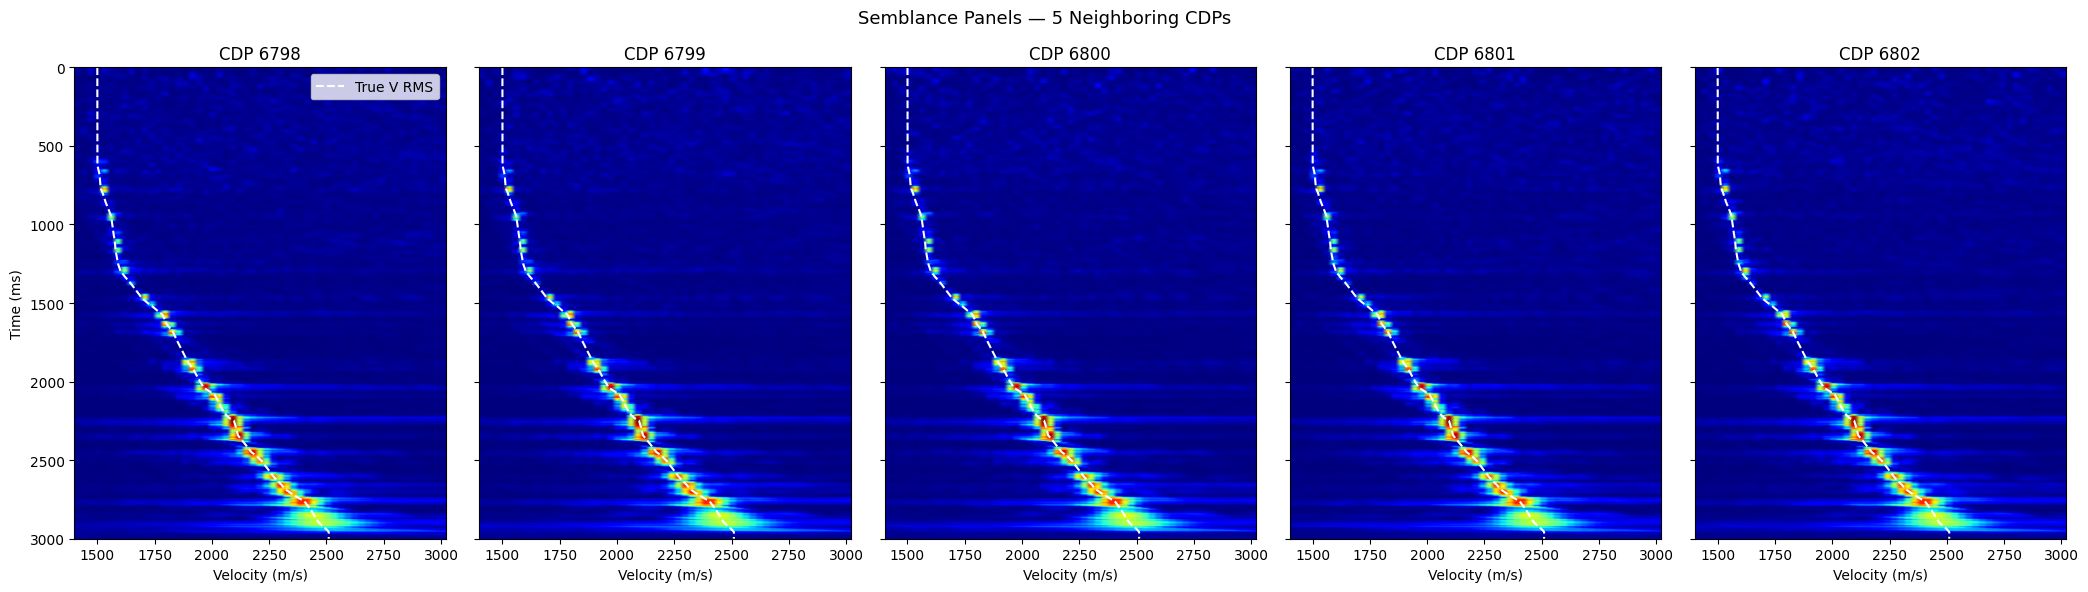

Figure saved.


In [18]:
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, N_CDPS, figsize=(4.2 * N_CDPS, 6), sharey=True)

for ax, p in zip(axes, panels):
    ax.imshow(
        p['semblance'].T, aspect='auto', cmap='jet',
        vmin=0, vmax=1,
        extent=[velocities[0], velocities[-1], p['t_grid'][-1], p['t_grid'][0]]
    )
    ax.plot(p['v_rms_true'], p['t_grid'], 'w--', linewidth=1.5, label='True V RMS')
    ax.set_xlabel('Velocity (m/s)')
    ax.set_title(f"CDP {p['cdp_idx']}")

axes[0].set_ylabel('Time (ms)')
axes[0].legend()
plt.suptitle('Semblance Panels — 5 Neighboring CDPs', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '02_semblance_before_picking.png'), dpi=150
)
plt.show()
print('Figure saved.')


## 5. Run Hill Climbing and Random Search

In [19]:
for p in panels:
    common = dict(
        traces=p['gather'], offsets=offsets_m, dt_ms=DT_MS,
        vel_min=VEL_MIN, vel_max=VEL_MAX, n_picks=N_PICKS,
        min_sep_ms=MIN_SEP_MS, t_min_ms=p['t_min_ms'], t_max_ms=T_MAX_PICK_MS,
    )

    hc = HillClimbing(
        seed=SEED, max_evals=MAX_EVALS,
        max_iter=MAX_ITER, restarts=RESTARTS,
        step_time=STEP_TIME, step_vel=STEP_VEL,
        n_neighbors=N_NEIGHBORS, patience=PATIENCE,
        **common
    )
    hc.run()

    rs = RandomSearch(seed=SEED, max_evals=MAX_EVALS, **common)
    rs.run()

    p['hc'], p['rs'] = hc, rs
    hc_t, hc_v = hc.get_result()
    rs_t, rs_v = rs.get_result()
    p['hc_times_ms'], p['hc_vels'] = hc_t * DT_MS, hc_v
    p['rs_times_ms'], p['rs_vels'] = rs_t * DT_MS, rs_v

    print(f"CDP {p['cdp_idx']:6d}  |  "
          f"HC: score={hc.best_score:.4f}  evals={hc.n_evals}  time={hc.exec_time_s:.2f}s  |  "
          f"RS: score={rs.best_score:.4f}  evals={rs.n_evals}  time={rs.exec_time_s:.2f}s")


CDP   6798  |  HC: score=0.5561  evals=33000  time=29.75s  |  RS: score=0.3760  evals=33000  time=34.00s
CDP   6799  |  HC: score=0.4898  evals=33000  time=28.95s  |  RS: score=0.3665  evals=33000  time=32.11s
CDP   6800  |  HC: score=0.3985  evals=33000  time=29.11s  |  RS: score=0.3655  evals=33000  time=32.31s
CDP   6801  |  HC: score=0.5679  evals=33000  time=29.39s  |  RS: score=0.3534  evals=33000  time=33.09s
CDP   6802  |  HC: score=0.4832  evals=33000  time=32.25s  |  RS: score=0.3299  evals=33000  time=38.14s


In [20]:
# Diagnostic detail for the center CDP, same as 01_hill_climbing.ipynb
center = next(p for p in panels if p['cdp_idx'] == CENTER_CDP)
hc = center['hc']

print(f'Hill Climbing on CDP {CENTER_CDP} (center column):')
print('Iterations per restart :', [len(h) - 1 for h in hc.restart_histories])
print('Final score per restart:', [round(s, 4) for s in hc.restart_scores])


Hill Climbing on CDP 6800 (center column):
Iterations per restart : [263, 300, 300, 300, 116]
Final score per restart: [0.2774, 0.1884, 0.0461, 0.073, 0.3985]


## 6. Visualize result

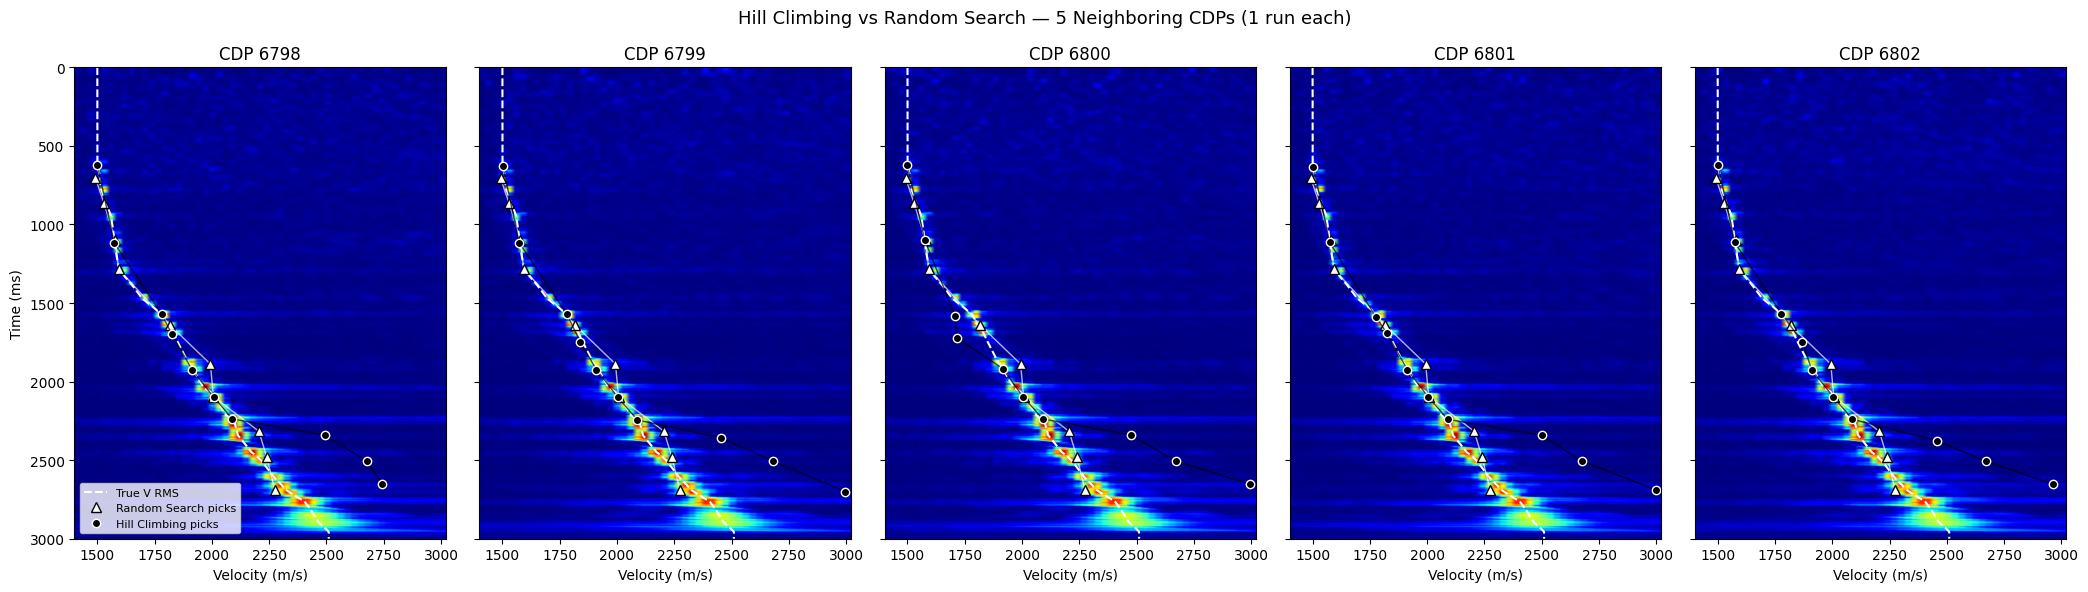

Figure saved.


In [21]:
fig, axes = plt.subplots(1, N_CDPS, figsize=(4.2 * N_CDPS, 6), sharey=True)

for ax, p in zip(axes, panels):
    ax.imshow(
        p['semblance'].T, aspect='auto', cmap='jet',
        vmin=0, vmax=1,
        extent=[velocities[0], velocities[-1], p['t_grid'][-1], p['t_grid'][0]]
    )
    ax.plot(p['v_rms_true'], p['t_grid'], 'w--', linewidth=1.5, label='True V RMS')
    ax.plot(p['rs_vels'], p['rs_times_ms'], 'w-', linewidth=1.0, alpha=0.7)
    ax.plot(p['rs_vels'], p['rs_times_ms'], '^', color='white',
            markeredgecolor='black', markersize=7, label='Random Search picks')
    ax.plot(p['hc_vels'], p['hc_times_ms'], 'k-', linewidth=1.0, alpha=0.7)
    ax.plot(p['hc_vels'], p['hc_times_ms'], 'o', color='black',
            markeredgecolor='white', markersize=6, label='Hill Climbing picks')
    ax.set_xlabel('Velocity (m/s)')
    ax.set_title(f"CDP {p['cdp_idx']}")

axes[0].set_ylabel('Time (ms)')
axes[0].legend(loc='lower left', fontsize=8)
plt.suptitle('Hill Climbing vs Random Search — 5 Neighboring CDPs (1 run each)', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '02_multi_cdp_picks.png'), dpi=150
)
plt.show()
print('Figure saved.')


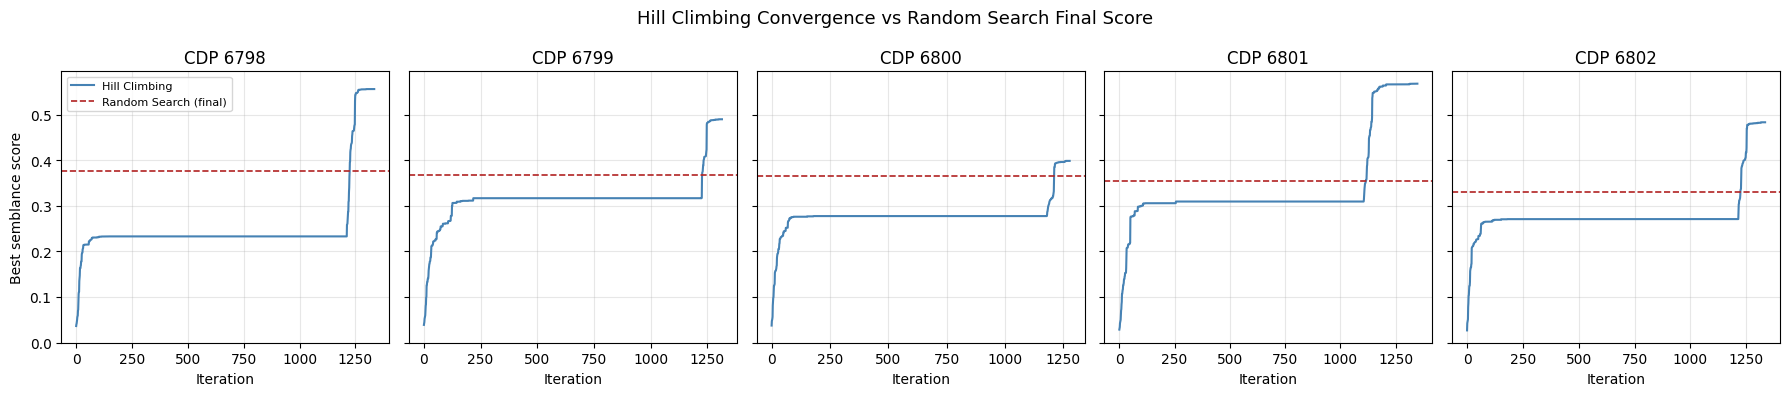

Figure saved.


In [22]:
fig, axes = plt.subplots(1, N_CDPS, figsize=(3.6 * N_CDPS, 4), sharey=True)

for ax, p in zip(axes, panels):
    ax.plot(p['hc'].history, color='steelblue', linewidth=1.5, label='Hill Climbing')
    ax.axhline(p['rs'].best_score, color='firebrick', linewidth=1.2,
               linestyle='--', label='Random Search (final)')
    ax.set_xlabel('Iteration')
    ax.set_title(f"CDP {p['cdp_idx']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Best semblance score')
axes[0].legend(fontsize=8)
plt.suptitle('Hill Climbing Convergence vs Random Search Final Score', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '02_multi_cdp_convergence.png'), dpi=150
)
plt.show()
print('Figure saved.')


## 7. Metrics

In [23]:
from src.analysis.metrics import velocity_errors, count_correct_picks

print(f'{"CDP":>8} {"Algorithm":>14} {"Score":>8} {"Correct":>9} '
      f'{"RMSE":>8} {"MAE":>8} {"Time (s)":>10}')
print('-' * 70)

for p in panels:
    for name, times_ms, vels, opt in [
        ('Hill Climbing', p['hc_times_ms'], p['hc_vels'], p['hc']),
        ('Random Search', p['rs_times_ms'], p['rs_vels'], p['rs']),
    ]:
        err = velocity_errors(times_ms, vels, p['t_grid'], p['v_rms_true'])
        cor = count_correct_picks(times_ms, vels, p['t_grid'], p['v_rms_true'])
        p[f'{name}_rmse'] = err['rmse']
        p[f'{name}_mae']  = err['mae']
        p[f'{name}_correct'] = cor['n_correct']
        print(f"{p['cdp_idx']:>8} {name:>14} {opt.best_score:>8.4f} "
              f"{cor['n_correct']:>6}/{N_PICKS} {err['rmse']:>8.1f} "
              f"{err['mae']:>8.1f} {opt.exec_time_s:>10.2f}")


     CDP      Algorithm    Score   Correct     RMSE      MAE   Time (s)
----------------------------------------------------------------------
    6798  Hill Climbing   0.5561      7/10    234.6    131.8      29.75
    6798  Random Search   0.3760      7/10     47.5     33.6      34.00
    6799  Hill Climbing   0.4898      7/10    275.5    149.5      28.95
    6799  Random Search   0.3665      7/10     47.6     33.7      32.11
    6800  Hill Climbing   0.3985      5/10    289.4    173.5      29.11
    6800  Random Search   0.3655      7/10     47.6     33.8      32.31
    6801  Hill Climbing   0.5679      7/10    285.8    156.7      29.39
    6801  Random Search   0.3534      7/10     47.8     33.9      33.09
    6802  Hill Climbing   0.4832      7/10    273.8    148.7      32.25
    6802  Random Search   0.3299      7/10     47.9     34.0      38.14


## 8. Save results

In [24]:
os.makedirs(os.path.join(project_root, 'results', 'metrics'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'results', 'picks'),   exist_ok=True)

summary = []
for p in panels:
    summary.append({
        'cdp': p['cdp_idx'],
        'water_bottom_ms': p['t_min_ms'],
        'hill_climbing': {
            'best_score':  float(p['hc'].best_score),
            'n_evals':     p['hc'].n_evals,
            'exec_time_s': float(p['hc'].exec_time_s),
            'rmse':        float(p['Hill Climbing_rmse']),
            'mae':         float(p['Hill Climbing_mae']),
            'n_correct':   int(p['Hill Climbing_correct']),
        },
        'random_search': {
            'best_score':  float(p['rs'].best_score),
            'n_evals':     p['rs'].n_evals,
            'exec_time_s': float(p['rs'].exec_time_s),
            'rmse':        float(p['Random Search_rmse']),
            'mae':         float(p['Random Search_mae']),
            'n_correct':   int(p['Random Search_correct']),
        },
    })

metrics_path = os.path.join(project_root, 'results', 'metrics',
                            'multi_cdp_visual.json')
with open(metrics_path, 'w') as f:
    json.dump(summary, f, indent=2)

picks_path = os.path.join(project_root, 'results', 'picks',
                          'multi_cdp_visual.npy')
np.save(picks_path, {
    p['cdp_idx']: {
        'hc_times_ms': p['hc_times_ms'], 'hc_vels': p['hc_vels'],
        'rs_times_ms': p['rs_times_ms'], 'rs_vels': p['rs_vels'],
    } for p in panels
})

print('Results saved:')
print(f'  Metrics : {metrics_path}')
print(f'  Picks   : {picks_path}')
print()
print(json.dumps(summary, indent=2))


Results saved:
  Metrics : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/multi_cdp_visual.json
  Picks   : /home/rafael-garcia/projetos/seismic-velocity-picking/results/picks/multi_cdp_visual.npy

[
  {
    "cdp": 6798,
    "water_bottom_ms": 601.67,
    "hill_climbing": {
      "best_score": 0.5560851402580738,
      "n_evals": 33000,
      "exec_time_s": 29.750629679999975,
      "rmse": 234.63704557981848,
      "mae": 131.77387317499696,
      "n_correct": 7
    },
    "random_search": {
      "best_score": 0.37602822110056877,
      "n_evals": 33000,
      "exec_time_s": 34.004500908999944,
      "rmse": 47.5326278469754,
      "mae": 33.64976136330167,
      "n_correct": 7
    }
  },
  {
    "cdp": 6799,
    "water_bottom_ms": 601.67,
    "hill_climbing": {
      "best_score": 0.4898309657350183,
      "n_evals": 33000,
      "exec_time_s": 28.952516441999933,
      "rmse": 275.46323423626677,
      "mae": 149.49950808496382,
      "n_correct": 7
    },
  

## 9. Summary

This is a **quick visual check** (the same per-run budget as the report,
a single run, no paired seeds across multiple repetitions) — the goal
is only to confirm that Hill Climbing and Random Search still behave
sensibly when applied to neighboring Marmousi2 columns, before moving
on to Tabu Search.

**What this notebook does NOT do yet:**
- No lateral continuity penalty between the 5 CDPs — each panel is
  still optimized independently.
- No statistical protocol (paired seeds, Wilcoxon test) — that stays
  for the full multi-CDP experiment once the lateral coupling exists.

**Next notebooks:**
- `03_tabu_search` — adds memory to avoid revisiting solutions
- a future multi-CDP notebook — couples the 5 panels with an explicit
  lateral-continuity penalty term in the objective function
